# 🛡️ ChurnShield — Customer Churn Prediction

**Objective:** Build an interpretable ML system to predict telecom customer churn and surface actionable retention insights using SHAP explainability.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — IBM Sample Dataset  
**Records:** 7,043 customers | **Features:** 20 | **Target:** Churn (Yes/No)

---
**Pipeline**
```
Data Loading → EDA → Preprocessing → Feature Engineering
→ Model Training (LR / RF / XGBoost) → Evaluation → SHAP → Export
```

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

# Colour palette
blue = '#90CAF9'
pink = '#F48FB1'
sns.set(style='whitegrid')
plt.rcParams.update({'figure.facecolor': '#fafafa', 'axes.facecolor': '#fafafa'})

print('✅ All libraries loaded.')

✅ All libraries loaded.


## 2. Load & Inspect Data

In [3]:
# Download from Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# Place CSV in the same directory or adjust path
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'\nChurn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')
df.head()

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n--- Basic Stats ---')
df.describe()

--- Data Types ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

--- Missing Values ---
Series([], dtype: int64)

--- Basic Stats ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Exploratory Data Analysis (EDA)

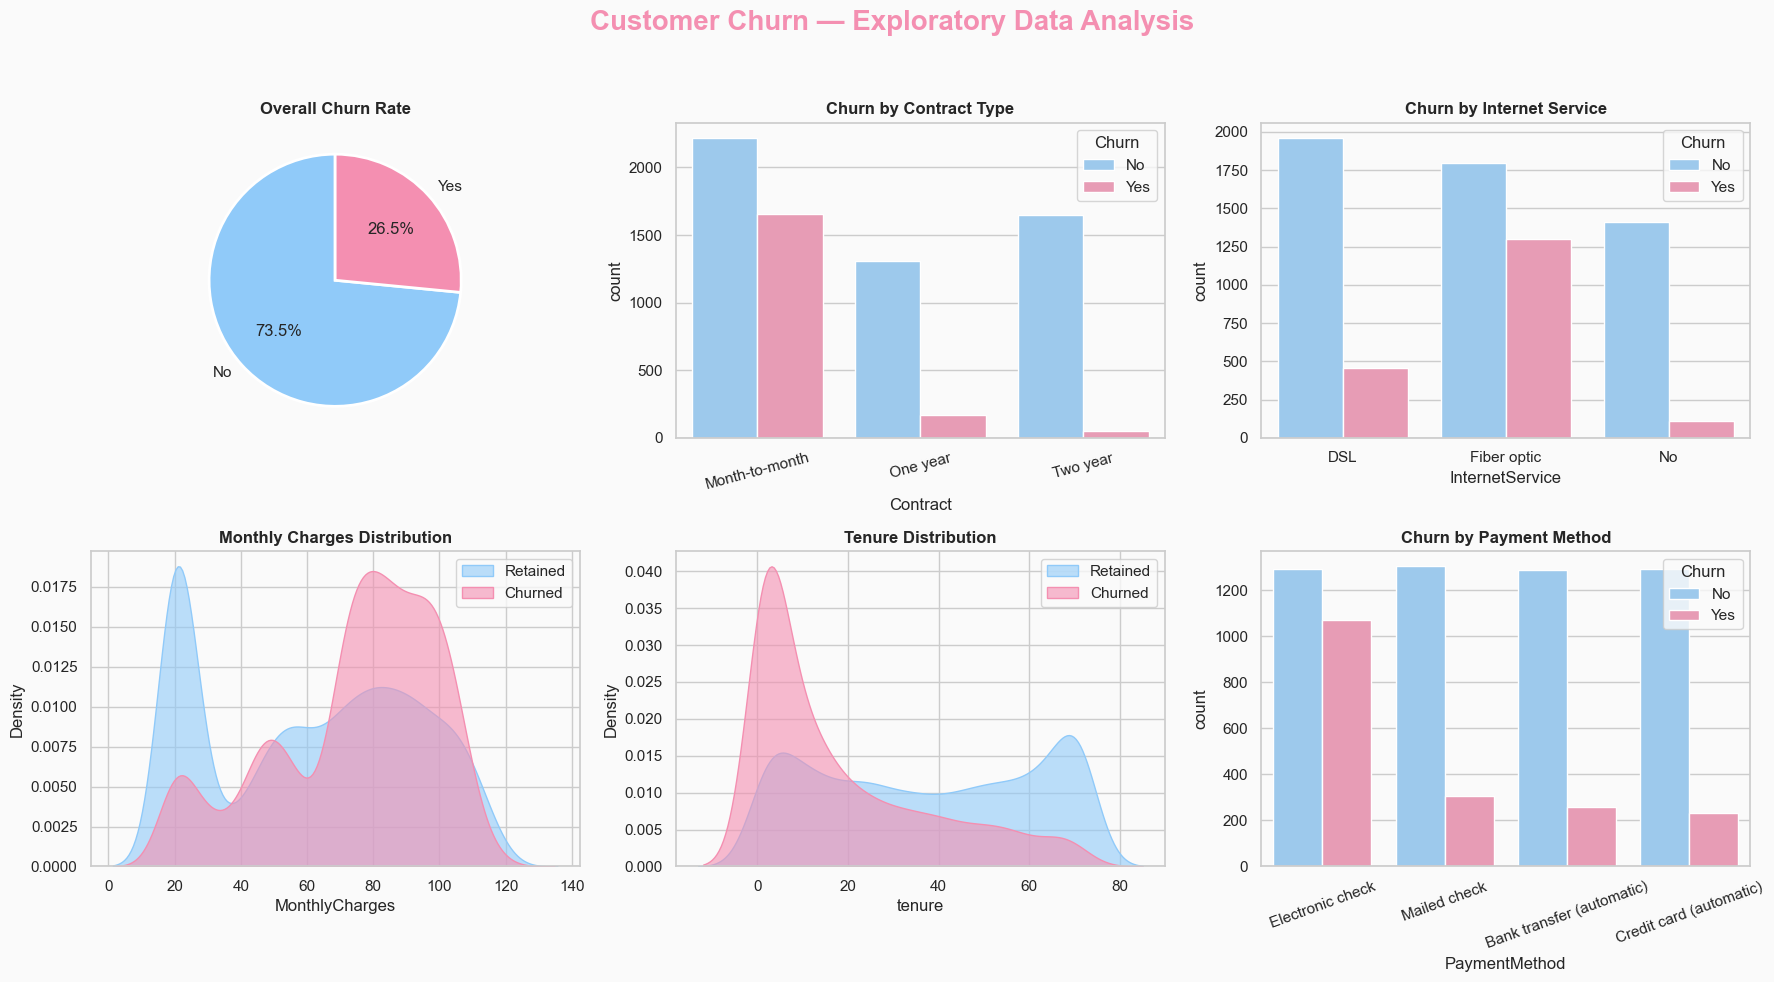

Key Insight: Month-to-month contracts + Fiber optic + Electronic check = highest churn risk


In [5]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn — Exploratory Data Analysis', fontsize=20, fontweight='bold', color=pink)

# Churn distribution
churn_counts = df['Churn'].value_counts()
axs[0, 0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
              colors=[blue, pink], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axs[0, 0].set_title('Overall Churn Rate', fontweight='bold')

# Contract type
sns.countplot(data=df, x='Contract', hue='Churn', palette=[blue, pink], ax=axs[0, 1])
axs[0, 1].set_title('Churn by Contract Type', fontweight='bold')
axs[0, 1].tick_params(axis='x', rotation=15)

# Internet service
sns.countplot(data=df, x='InternetService', hue='Churn', palette=[blue, pink], ax=axs[0, 2])
axs[0, 2].set_title('Churn by Internet Service', fontweight='bold')

# Monthly charges distribution
sns.kdeplot(df[df['Churn']=='No']['MonthlyCharges'], ax=axs[1, 0],
            label='Retained', fill=True, color=blue, alpha=0.6)
sns.kdeplot(df[df['Churn']=='Yes']['MonthlyCharges'], ax=axs[1, 0],
            label='Churned', fill=True, color=pink, alpha=0.6)
axs[1, 0].set_title('Monthly Charges Distribution', fontweight='bold')
axs[1, 0].legend()

# Tenure distribution
sns.kdeplot(df[df['Churn']=='No']['tenure'], ax=axs[1, 1],
            label='Retained', fill=True, color=blue, alpha=0.6)
sns.kdeplot(df[df['Churn']=='Yes']['tenure'], ax=axs[1, 1],
            label='Churned', fill=True, color=pink, alpha=0.6)
axs[1, 1].set_title('Tenure Distribution', fontweight='bold')
axs[1, 1].legend()

# Payment method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=[blue, pink], ax=axs[1, 2])
axs[1, 2].set_title('Churn by Payment Method', fontweight='bold')
axs[1, 2].tick_params(axis='x', rotation=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('assets/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Insight: Month-to-month contracts + Fiber optic + Electronic check = highest churn risk')

## 4. Preprocessing

In [6]:
# Fix TotalCharges — it's object type due to empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'NaN in TotalCharges after conversion: {df["TotalCharges"].isna().sum()}')

# Fill NaNs (11 rows with 0 tenure — new customers, TotalCharges should be 0)
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID — not a feature
df.drop('customerID', axis=1, inplace=True)

print('✅ Preprocessing complete.')
print(f'Shape after cleaning: {df.shape}')

NaN in TotalCharges after conversion: 11
✅ Preprocessing complete.
Shape after cleaning: (7043, 20)


## 5. Feature Engineering

In [7]:
# Domain-motivated features
df['AvgChargesPerMonth']       = df['TotalCharges'] / (df['tenure'] + 1)
df['HighMonthlyCharge']        = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
df['IsLongTerm']               = (df['Contract'] != 'Month-to-month').astype(int)
df['Tenure_Charge_Interaction']= df['tenure'] * df['MonthlyCharges']

print('New features added:')
print('  AvgChargesPerMonth       — average spend per month of tenure')
print('  HighMonthlyCharge        — binary flag: above median monthly charge')
print('  IsLongTerm               — binary flag: 1-year or 2-year contract')
print('  Tenure_Charge_Interaction— interaction term: tenure × monthly charges')
print(f'\nFinal feature count: {df.shape[1] - 1}')

New features added:
  AvgChargesPerMonth       — average spend per month of tenure
  HighMonthlyCharge        — binary flag: above median monthly charge
  IsLongTerm               — binary flag: 1-year or 2-year contract
  Tenure_Charge_Interaction— interaction term: tenure × monthly charges

Final feature count: 23


## 6. Encode & Split

In [8]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Churn rate in train: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test : {y_test.mean()*100:.1f}%')

# Save column order for the Streamlit app
joblib.dump(list(X.columns), 'models/model_columns.pkl')
print('\n✅ model_columns.pkl saved.')

Training set : 5634 samples
Test set     : 1409 samples
Churn rate in train: 26.5%
Churn rate in test : 26.5%

✅ model_columns.pkl saved.


In [11]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes'].astype(int)

# Add this:
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 7. Model Training & Comparison

In [12]:
results = {}

# --- Logistic Regression (baseline) ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'roc_auc' : roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
    'f1_churn': float(classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score'])
}
print(f'Logistic Regression  → Acc: {results["Logistic Regression"]["accuracy"]:.4f} | ROC-AUC: {results["Logistic Regression"]["roc_auc"]:.4f}')

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'roc_auc' : roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
    'f1_churn': float(classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score'])
}
print(f'Random Forest        → Acc: {results["Random Forest"]["accuracy"]:.4f} | ROC-AUC: {results["Random Forest"]["roc_auc"]:.4f}')

# --- XGBoost (tuned) ---
xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.7,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'roc_auc' : roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
    'f1_churn': float(classification_report(y_test, y_pred_xgb, output_dict=True)['1']['f1-score'])
}
print(f'XGBoost              → Acc: {results["XGBoost"]["accuracy"]:.4f} | ROC-AUC: {results["XGBoost"]["roc_auc"]:.4f}')

Logistic Regression  → Acc: 0.8133 | ROC-AUC: 0.8478
Random Forest        → Acc: 0.7878 | ROC-AUC: 0.8297
XGBoost              → Acc: 0.7999 | ROC-AUC: 0.8467


## 8. Evaluation

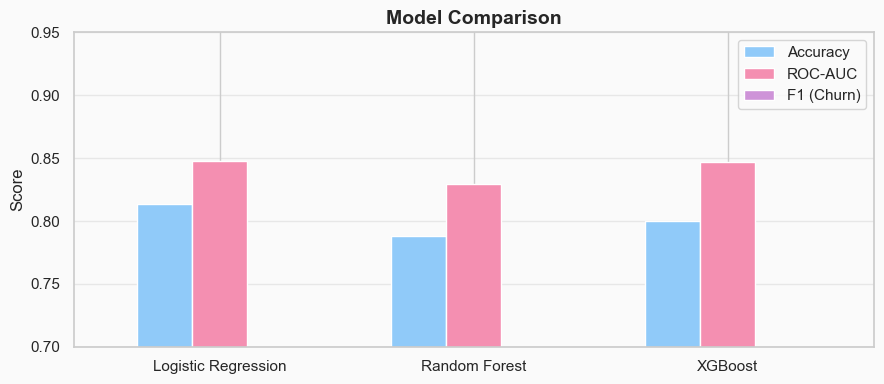

In [13]:
# Model comparison bar chart
metrics_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(9, 4))
metrics_df[['accuracy','roc_auc','f1_churn']].plot(
    kind='bar', ax=ax,
    color=[blue, pink, '#CE93D8'],
    edgecolor='white', width=0.65
)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_df.index, rotation=0)
ax.set_ylim(0.7, 0.95)
ax.legend(['Accuracy', 'ROC-AUC', 'F1 (Churn)'])
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Full classification report for best model (XGBoost)
print('=== XGBoost — Classification Report ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Retained','Churned']))

=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

    Retained       0.84      0.90      0.87      1035
     Churned       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



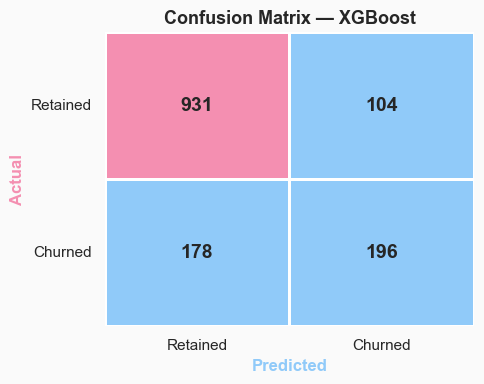

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap=sns.color_palette([blue, pink], as_cmap=True),
            cbar=False, annot_kws={'size':14,'weight':'bold'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold', color=blue)
ax.set_ylabel('Actual',    fontsize=12, fontweight='bold', color=pink)
ax.set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Retained','Churned'])
ax.set_yticklabels(['Retained','Churned'], rotation=0)
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

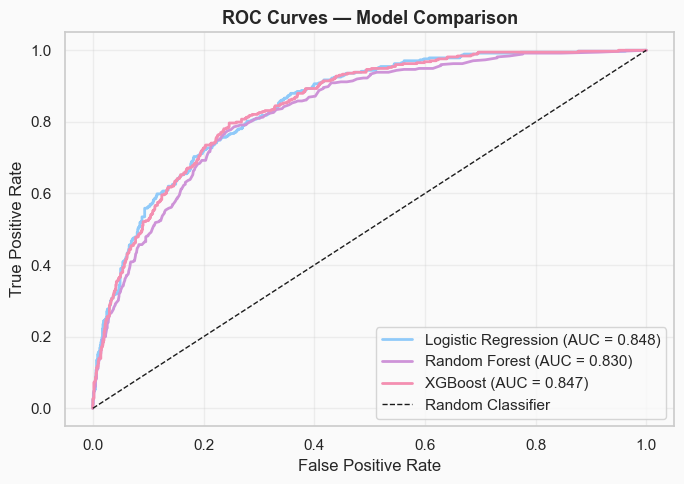

In [16]:
# ROC Curves — all three models
fig, ax = plt.subplots(figsize=(7, 5))

for name, clf, color in [
    ('Logistic Regression', lr,  '#90CAF9'),
    ('Random Forest',        rf,  '#CE93D8'),
    ('XGBoost',              xgb, '#F48FB1'),
]:
    fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SHAP Explainability

In [17]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values computed for {X_test.shape[0]} test samples across {X_test.shape[1]} features.')

SHAP values computed for 1409 test samples across 34 features.


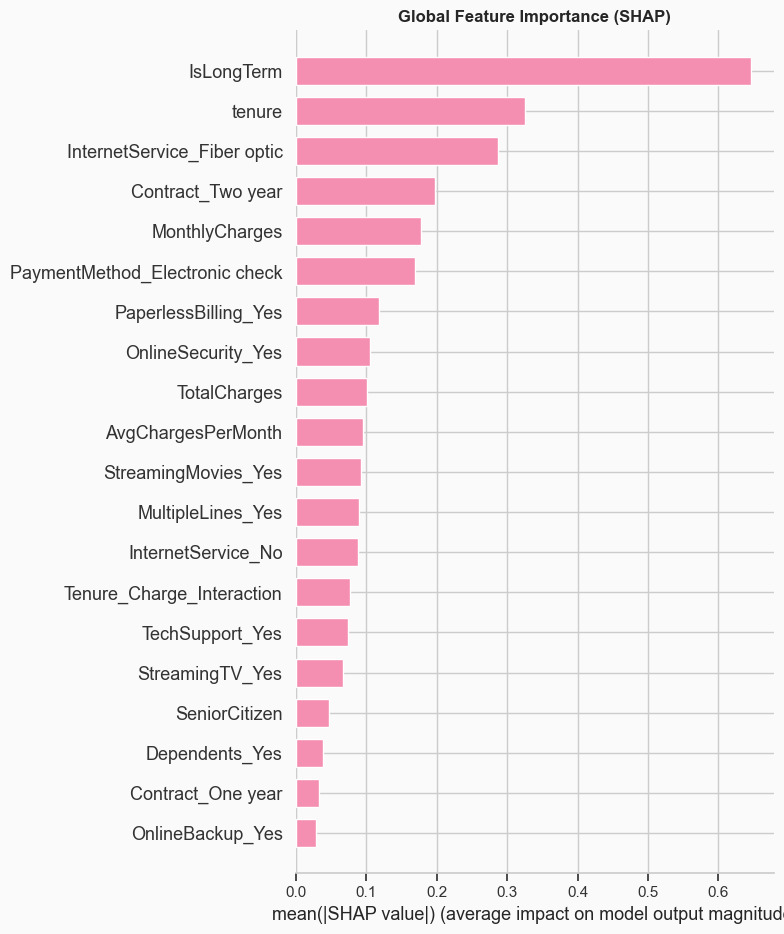

In [18]:
# Global feature importance (bar)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar', color=pink, show=False)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

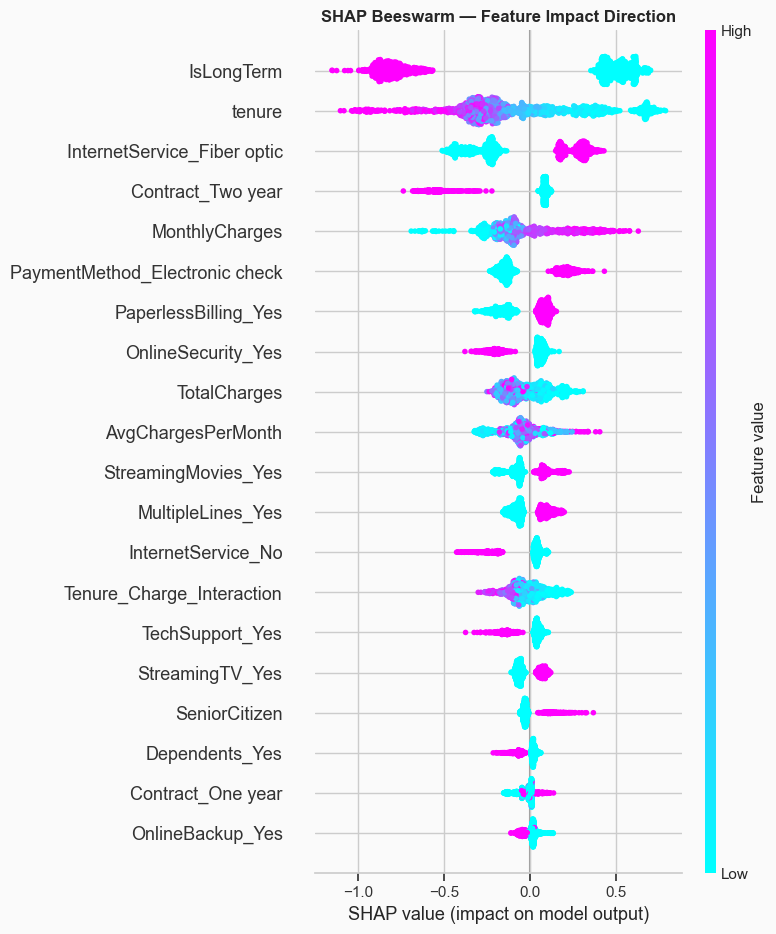

In [19]:
# Beeswarm — shows direction of impact
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, cmap='cool', show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

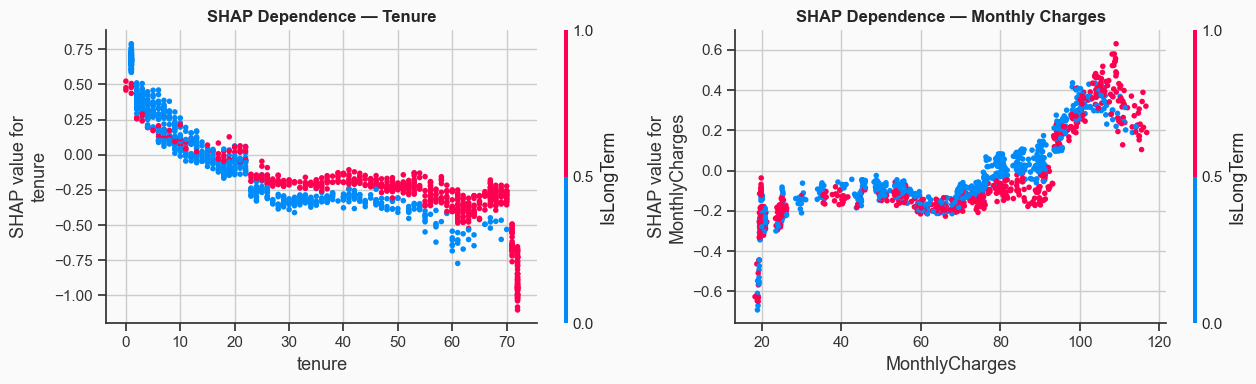

In [20]:
# Dependence plots for top two features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plt.sca(axes[0])
shap.dependence_plot('tenure', shap_values, X_test, ax=axes[0], show=False)
axes[0].set_title('SHAP Dependence — Tenure', fontweight='bold')

plt.sca(axes[1])
shap.dependence_plot('MonthlyCharges', shap_values, X_test, ax=axes[1], show=False)
axes[1].set_title('SHAP Dependence — Monthly Charges', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Export Model

In [21]:
joblib.dump(xgb, 'models/churnshield_model.pkl')
print('✅ Model saved to models/churnshield_model.pkl')
print('✅ Columns saved to models/model_columns.pkl')

print('\n=== Final Model Summary ===')
for model_name, m in results.items():
    print(f'{model_name:<22} Accuracy: {m["accuracy"]:.4f}  ROC-AUC: {m["roc_auc"]:.4f}  F1(Churn): {m["f1_churn"]:.4f}')

✅ Model saved to models/churnshield_model.pkl
✅ Columns saved to models/model_columns.pkl

=== Final Model Summary ===
Logistic Regression    Accuracy: 0.8133  ROC-AUC: 0.8478  F1(Churn): 0.6127
Random Forest          Accuracy: 0.7878  ROC-AUC: 0.8297  F1(Churn): 0.5517
XGBoost                Accuracy: 0.7999  ROC-AUC: 0.8467  F1(Churn): 0.5816
